In [ ]:
# If you're using Google Colab, you can run this cell to upgrade the required dependencies
#!pip install matplotlib==3.4.3
#!pip install --upgrade statsmodels

# Module 7. Time series

## Introduction

Many decision-making processes rely on forecasts of future values, such as sales, demand, or economic indicators. However, forecasting is inherently challenging, both in the short term and in the long term. Most forecasts are based on historical data, where analysts attempt to identify patterns or relationships and then project these into the future.

This approach comes with two major limitations.

First, it is often difficult to distinguish meaningful patterns from noise—that is, random fluctuations in the data. As a result, analysts may sometimes overinterpret randomness and assign significance to patterns that are unlikely to persist.

Second, even when genuine patterns are identified, there is no guarantee that they will continue in the future. External factors—such as economic crises, geopolitical events, technological changes, or shifts in consumer behavior—can disrupt historical trends and render forecasts inaccurate.

### Extrapolation Models

Extrapolation models are quantitative methods that use historical time series data to predict future values. The underlying assumption is that past behavior of a variable—such as company sales or exports—contains useful information about its future evolution.

There are several widely used extrapolation techniques, including:

- Moving averages  
- Exponential smoothing  
- Trend projection models  

These models aim to identify patterns in historical data and extend them into the future. Some models focus on capturing long-term upward or downward trends, while others emphasize recurring seasonal patterns. For example, a retailer may observe higher sales during the holiday season and incorporate this pattern into future forecasts.

Although extrapolation models are relatively simple and often effective in stable environments, their performance can deteriorate when structural changes occur in the underlying system.

### Components of Time Series Data


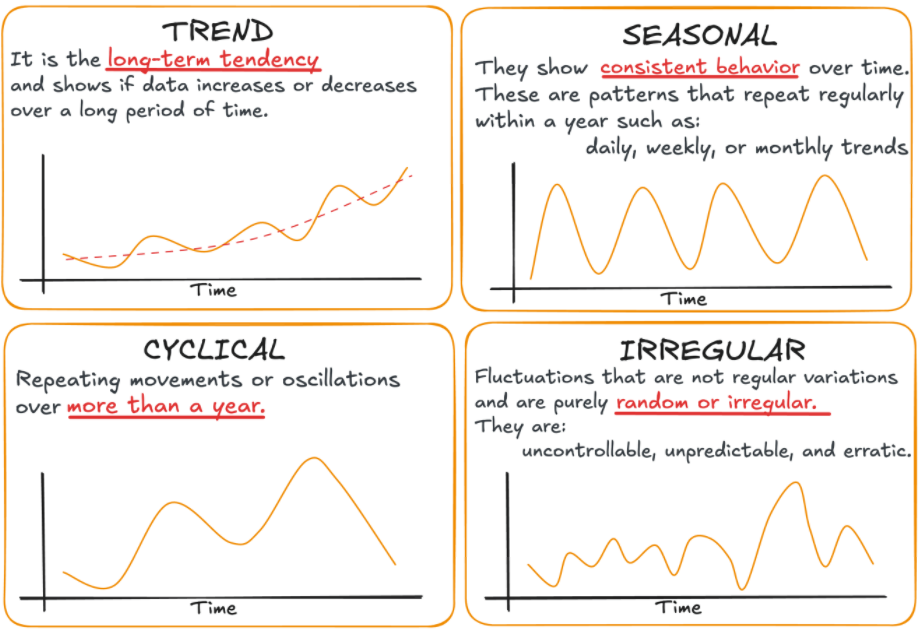


A time series typically consists of four main components:

#### 1. Trend Component

The trend represents the long-term direction of the data. If observations consistently increase or decrease over time, the series is said to exhibit a trend. Trends can be linear or nonlinear and are often driven by underlying factors such as economic growth, population changes, or technological progress.

#### 2. Seasonal Component

The seasonal component captures regular patterns that repeat over a fixed period, such as days, months, or quarters. For example, a company selling swimming pool equipment will typically see increased sales in spring and summer, followed by a decline in autumn and winter. Seasonal patterns are generally predictable and recur consistently over time.

#### 3. Cyclical Component

Cyclical patterns refer to fluctuations that occur over longer, irregular periods and are not tied to a fixed calendar. These are often associated with economic cycles, such as expansions and recessions. For instance, during an economic downturn, housing sales may decrease and unemployment may rise, while the opposite occurs during periods of growth.

The key distinction between seasonal and cyclical components is that seasonal patterns have a fixed and known period, whereas cyclical fluctuations vary in length and intensity.

#### 4. Random (Noise) Component

The random component, also known as noise, represents unpredictable variations in the data. These fluctuations arise from unforeseen events, measurement errors, or inherently random behavior. This component gives time series data its irregular, jagged appearance and cannot be reliably predicted.

### Conclusion

In practice, effective forecasting involves identifying and modeling the trend, seasonal, and cyclical components while acknowledging the presence of randomness. Although no model can perfectly predict the future, understanding these components helps analysts make more informed and robust forecasts.



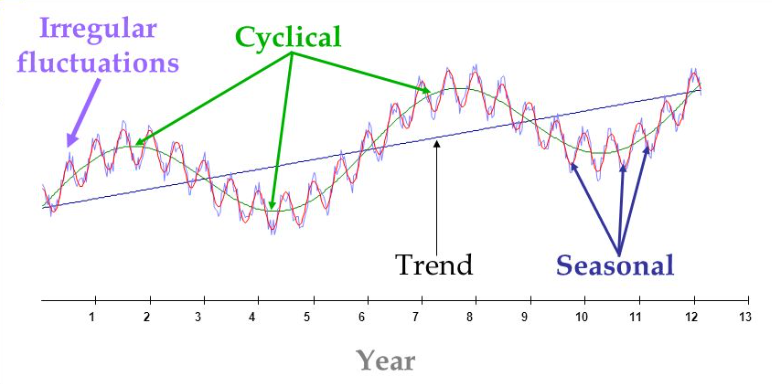


The figure below shows the decomposition of the pregnancy number time series (top panel) into thee components: trend, seasonality, and residuals. [Published in Annual review of public health 2006 On time series analysis of public health and biomedical data. S. Zeger, R. Irizarry, R. Peng]


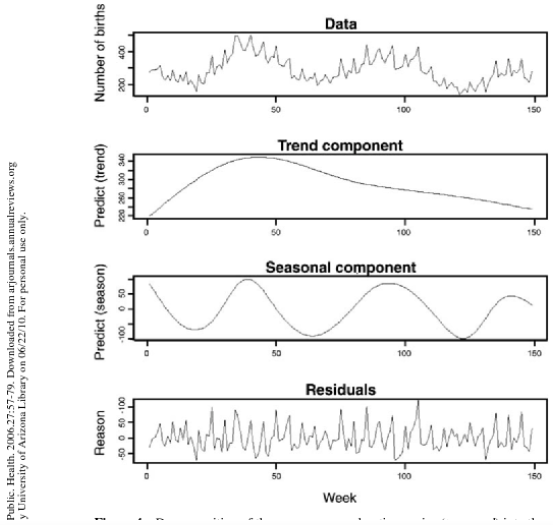

In [ ]:
# Package imports
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe

import scipy.stats as stats                         # Statistical tests
from sklearn.linear_model import LinearRegression   # Linear regression model

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

In this notebook, we use the figures on the
number of seriously injured victims of road traffic accidents in Belgium. These figures are sourced from [StatBel](https://bestat.statbel.fgov.be/bestat/crosstable.xhtml?view=9090f429-32f6-40c3-a685-04cef7b6b0f1).  
Remark that when creating the index for the data frame, we set the frequency to `MS`, i.e. Month Start, since each observation is taken at the first day of the month. A list of valid frequencies ([offset aliases](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases)) can be found [in the Pandas documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases). Frequently used values are:

|Alias|Description|
|---|---|
|D|calendar day frequency|
|W|weekly frequency|
|MS|month start frequency|
|ME|month end frequency|
|QS|quarter start frequency|
|QE|quarter end frequency|
|YS|year start frequency|
|YE|year end frequency|



In [ ]:
# Read the data from CSV, parse dates and set the index
wounded_data = pd.read_csv(
    'https://raw.githubusercontent.com/HoGentTIN/dsai-labs/refs/heads/main/data/number_of_heavily_wounded_car_accidents_BE.txt',
    delimiter = "\t",
    parse_dates=['date']).set_index(['date'])

# Add frequency info to the index
wounded_data.index = pd.DatetimeIndex(wounded_data.index, freq='MS')

wounded_data.head()

,number_of_heavily_wounded
date,
2013-01-01,285
2013-02-01,276
2013-03-01,332
2013-04-01,381
2013-05-01,393


In Python, a time series can also be represented by an instance of the Pandas [`Series`](https://pandas.pydata.org/docs/reference/api/pandas.Series.html) class with an index of type DatetimeIndex.

As always, a graph of the time series is a good place to start analyzing the data. It indicates whether a linear trend is likely to provide a good fit. Generally, the graph should rise or fall at approximately a constant rate through time, without too much random (unpredictable) variation.

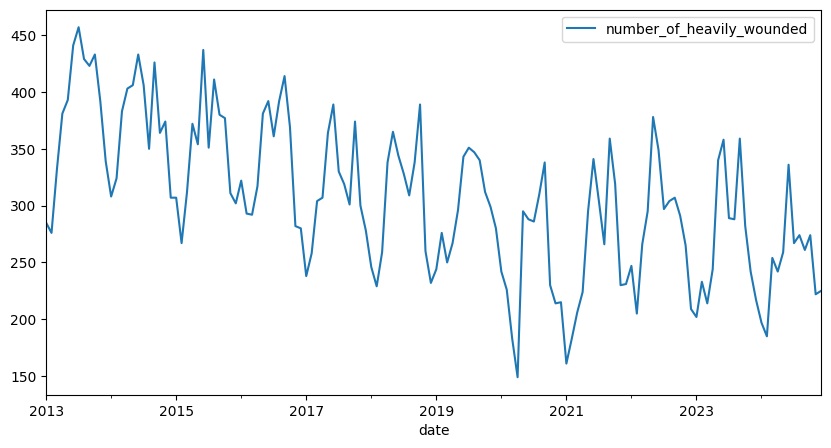

In [ ]:
wounded_data.plot(y='number_of_heavily_wounded', figsize=(10,5));

### Interludium

- What is the trend?
- What would you do to 'calculate' the exact trend?
- What is the seasonal component?
- Try to predict the number of heavily wounded for january 2025, based on the number of december 2024.
- Try to predict the number of heavily wounded for february 2025, based on the number of december 2024.
- Try to predict the number of heavily wounded for march 2025, based on the number of december 2024.

### Overview of the notebook

In this notebook we will study six methods to predict future values based on time series data.

(1) Horizontal line / Constant model  
(2) Simple linear regression  
(3) Simple moving average  
(4) Simple exponentional smoothing  
(5) Double exponentional smoothing  
(6) Triple exponentional smoothing  

Note that numerous other models are available for use in time series analysis!


## Mean absolute error and mean squared error
We need a metric to evaluate how accurate a forecasting model is. To do so, Mean Absolute Error (MAE) and Mean Squared Error (MSE) are often used by measuring the difference between predicted values and actual outcomes.  
MAE and MSE help assess model performance and compare different forecasting methods, allowing analysts to choose the most appropriate model for a given problem.  
**Mean Absolute Error (MAE)**  
The mean absolute error measures the average of the absolute differences between predicted values and actual values. It indicates how far, on average, the predictions are from the true values, regardless of direction. The MAE is easy to interpret (same units as the data) and is less sensitive to large errors (outliers).  

$$MAE = \frac{1}{m} \sum_{i=t+1}^{t+m} \left| x_i - F_i \right|$$

**Mean Squared Error (MSE)**  
The mean squared error measures the average of the squared differences between predicted values and actual values. By squaring the errors, larger mistakes are penalized more heavily. Therefore it is more sensitive to large errors (outliers).

$$MSE = \frac{1}{m} \sum_{i=t+1}^{t+m} (x_i - F_i)^{2}$$


## (1) Constant Model (Horizontal Line)

We start with the simplest model. In this approach, future values are predicted using nothing more than the average of a selected number of past observations.

In the chart below, we attempt to model the observed values using a constant function:

$X_t = b + \varepsilon_t$,

where $\varepsilon_t$ represents random noise with constant variance.

As an estimate for $b$, we take the average of the first observations. The number of observations to include can be chosen based on the analyst’s judgment.

### Why is this useful?

Despite its simplicity, this model has several advantages:

- It is easy to understand and implement.
- It provides a **baseline model** against which more complex models can be compared.
- It works reasonably well when the data fluctuates around a stable mean (i.e., no clear trend or seasonality).
- It reduces the impact of random fluctuations by averaging past observations.


### Why is this often too simple?

In most real-world applications, this model is too limited:

- It **ignores trends** (e.g., increasing sales over time).
- It **does not capture seasonality** (e.g., higher sales in certain months).
- It assumes the future will behave like a constant average, which is rarely realistic.
- It reacts slowly (or not at all) to structural changes in the data.
- The choice of how many past observations to include is subjective and can strongly affect the results.

### Conclusion

The constant model is a useful starting point and benchmark, but it is generally insufficient for capturing the complexity of real-world time series data. More advanced models are typically required to account for trends, seasonal patterns, and other dynamics.


### Example

In the example below the first 80 values are used as past observations. Although this model has clear limitations, it remains useful as it provides a rough estimate of the monthly number of people seriously injured in traffic accidents in Belgium. It indicates that this number is approximately 340 per month, rather than, for example, 1000 or 100.

Approximation of the number of heavily wounded in Belgian traffic per month = 338.925


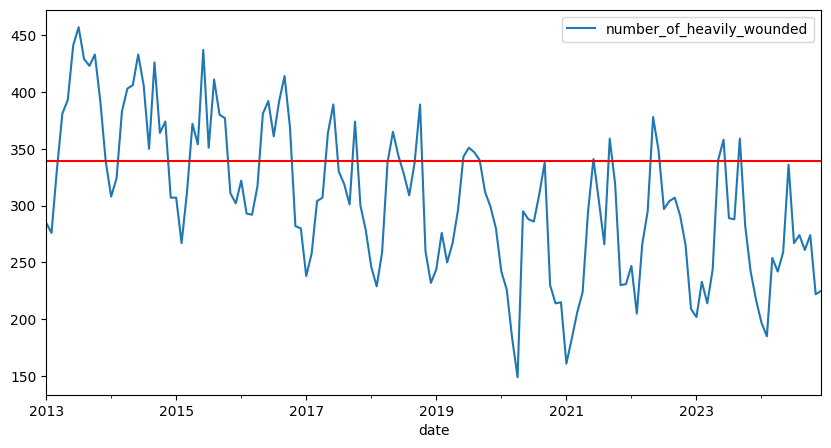

In [ ]:
# first 80 values are used as a past observations
b_est_80 = wounded_data['number_of_heavily_wounded'][:80].mean()
print(f'Approximation of the number of heavily wounded in Belgian traffic per month = {b_est_80}')

wounded_data.plot(y='number_of_heavily_wounded', figsize=(10,5))
plt.axhline(y=b_est_80, color='red');   # Mean of first 80 observations

## Train and test data

As already mentioned, two commonly used metrics for evaluating different forecasting methods are MAE and MSE. In this notebook we will compute the MAE for each of the six methods discussed. To be able to calculate the MAE, we need to split the available data into **training data** and **test data**. When building a machine learning model, this is a very common approach.  
The main reason for this split is to evaluate how well the model generalizes to new, unseen data. The model learns patterns from the training set, while the test set is used to provide an unbiased estimate of its performance. Without this separation, a model might simply memorize the data (overfitting) and appear to perform well, even though it fails on new inputs.

In many standard machine learning problems, the data is randomly divided into training and test sets. This works because the observations are assumed to be independent and identically distributed.

However, in the case of time series data, this approach is not appropriate. Time series data has a natural temporal order, and future values should not influence the past. Randomly shuffling the data would break this structure and lead to overly optimistic performance estimates.

Instead, the split is done chronologically. The training set consists of earlier observations, and the test set contains more recent data. The model is trained on historical data and then evaluated on its ability to predict future values. This setup reflects real-world scenarios, where only past information is available at prediction time.

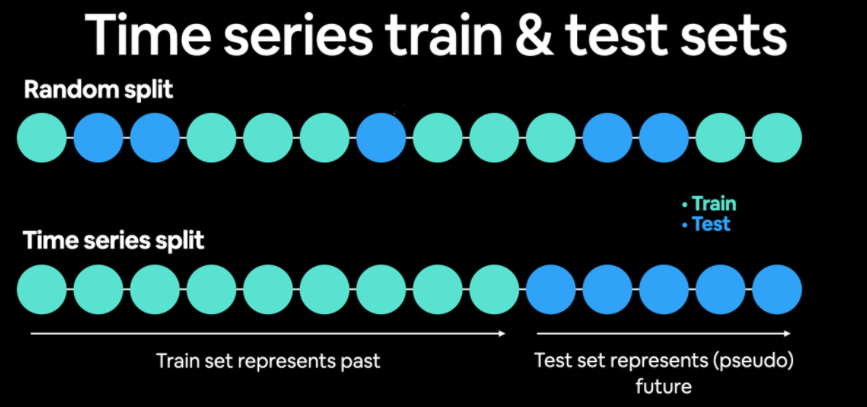

### Exercise

1. Create training data, i.e. the all data up to and including 2023
2. Create test data, i.e all data from 2024
3. Calculate the MAE


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

train = wounded_data[:'2023-12-01']
test = wounded_data['2024-01-01':]


## (2) Linear Trend Model (Simple Linear Regression)

We now consider a slightly more advanced model that allows for a trend over time. Instead of assuming a constant value, we assume that the data evolves linearly.

In this approach, the observed values are modeled using a linear function:

 $X_t = b_0 + b_1 t + \varepsilon_t$

where:

- $b_0$ is the intercept, this is less important. It literally represents the expected value of the series at time $t = 0$.
- $b_1$ represents the slope (trend), it represents the expected change in the series from one period to the next. If $b_1$ is positive, the trend is upward; if $b_1$ is negative, the trend is downward.
- $\varepsilon_t$ is random noise with constant variance.

The parameters $b_0$ and $b_1$ are typically estimated using ordinary least squares, which fits the best straight line through the observed data.

### Why is this useful?

This model improves upon the constant model in several ways:

- It captures **trends over time** (increasing or decreasing patterns).
- It is still relatively **simple and easy to interpret**.
- It provides a better approximation when the data shows a clear upward or downward movement.
- It can serve as a **next-step benchmark model** after the constant model.


### Why is this still limited?

Despite being more flexible than the constant model, this approach also has important limitations:

- It assumes the trend is **linear**, which is often unrealistic in practice.
- It does not account for **seasonality** (e.g., recurring yearly patterns).
- It ignores **cyclical behavior** and structural changes.
- It may perform poorly if the trend changes over time (e.g., accelerates or slows down).
- It is sensitive to outliers, which can distort the estimated line.


### Conclusion

The linear trend model is a natural extension of the constant model and is useful when the data exhibits a clear trend. However, like the constant model, it remains a simplification of reality. In many real-world time series, more advanced models are needed to capture seasonal effects, nonlinear trends, and other complex dynamics.

### Example

In the exampled below, all observations are used to estimate the line of best fit.  We first use `numpy.polyfit` to calculate the slope and intercept, afterwards `sklearn` is used.  
Since `numpy.polyfit` requires numerical x-values and our dataframe `wounded_data`uses dates as an index, we need to convert the time variable into numbers first.

In [ ]:
# Build a linear regression model using np.polyfit
y = wounded_data["number_of_heavily_wounded"].values
x = np.arange(len(y))  # 0,1,2,...

b1, b0 = np.polyfit(x=x, y=y, deg=1)
print(f'Equation of the regression line: y = {b0} + {b1} * t')

Equation of the regression line: y = 375.1980842911878 + -0.962657744554297 * t


In [ ]:
# Build a linear regression model using sklearn
from sklearn.linear_model import LinearRegression

x = np.arange(len(wounded_data)).reshape(-1, 1)
y = wounded_data['number_of_heavily_wounded'].values

wounded_lrm = LinearRegression().fit(x, y)
b0 = wounded_lrm.intercept_
b1 = wounded_lrm.coef_[0]
print(f'Equation of the regression line: y = {b0} + {b1} * t')

Equation of the regression line: y = 375.19808429118774 + -0.9626577445542965 * t


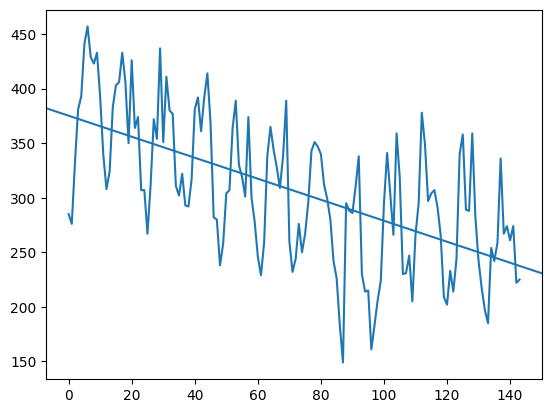

In [ ]:
# plot the time series and the regression line
plt.plot(x, y);
plt.axline((0, b0), slope=b1);

### Exercises

1. What 'proves' in the previous model the trend is actually descending?
2. What is the meaning of $b_0$ in the previous model?
3. What is the meaning of $b_1$ in the previous model?
4. What is an important shortcoming of the linear regression model?
5. Calculate the MAE
    * Create trainingsdata, i.e. the all data up to and including 2023
    * Create testdata, i.e all data from 2024
    * Calculate the equation of the regression line based on the trainingsdata
    * Using this linear regression model, generate forecasts for the period from January 2024 through December 2024.
    * Calculate the mean absolute error.

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

# Build a linear regression model using np.polyfit
train = wounded_data[:'2023-12-01']
test = wounded_data['2024-01-01':]



Equation of the regression line: y = 376.78742310321263 + -0.9964075699310756 * t
The MAE is 31.61827278118966


## (3) Simple Moving Average (SMA)

### Introduction

The available data are given on a monthly basis, and a time window of six months is selected. Suppose the forecast for the next month is then calculated as the average of the values from the previous six months. For example, the average of January through June is used to predict July, the average of February through July is used to predict August, and so on. This rolling procedure gives rise to the term **moving average**.

The choice of the time window (or span) plays a crucial role. If the window is large—say, 12 months—each average is based on many observations, which reduces the influence of extreme values. As a result, the forecast series becomes smoother than the original data.

In contrast, if the window is small—say, three months—each average is based on fewer observations. This makes the forecasts more sensitive to extreme values, resulting in a series that is less smooth and more responsive to short-term fluctuations.

### Formula

We basically need a method that takes the last observations into account, but forgets observations after some time. Older observations may no longer be representative of the current situation. Moving averages are such methods.

$$SMA(t) = \frac{1}{m} \sum_{i=k}^{t} x_i$$

With $m$ the window size (the number of observations taken into account) and $k$ = t - m + 1.


### Why is this useful?

- It smooths out short-term fluctuations in the data.
- It adapts over time.
- It is easy to understand and implement.
- It works well when the data has no strong trend or seasonality.


### Why is this still limited?

- It gives equal weight to all \( k \) past observations, even though more recent data may be more relevant.
- It does not capture trends (it tends to lag behind increasing or decreasing data).
- It does not account for seasonality.
- The choice of \( k \) is subjective and can significantly affect the results.


### Conclusion

The simple moving average provides a more flexible way to smooth data and make short-term forecasts, but it still has important limitations. More advanced methods are often needed for time series with trends or seasonal patterns.


### Example
The Pandas `Series` class has a method [`rolling()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html) for "rolling window" calculations, which is perfectly suitable for what we want to do here.

We call the method `rolling(m)` with the desired time range and then calculate the `mean()`:


In [ ]:
wounded_data['SMA3'] = wounded_data['number_of_heavily_wounded'].rolling(3).mean()
wounded_data['SMA5'] = wounded_data['number_of_heavily_wounded'].rolling(5).mean()
wounded_data['SMA10'] = wounded_data['number_of_heavily_wounded'].rolling(10).mean()
wounded_data.head(15)

,number_of_heavily_wounded,SMA3,SMA5,SMA10
date,,,,
2013-01-01,285,NaN,NaN,NaN
2013-02-01,276,NaN,NaN,NaN
2013-03-01,332,297.666667,NaN,NaN
2013-04-01,381,329.666667,NaN,NaN
2013-05-01,393,368.666667,333.4,NaN
2013-06-01,441,405.000000,364.6,NaN
2013-07-01,457,430.333333,400.8,NaN
2013-08-01,429,442.333333,420.2,NaN
2013-09-01,423,436.333333,428.6,NaN


You'll notice that the first data points in the SMA columns are empty (`NaN`). At those time slots there are still not enough past observations to calculate the mean. The larger the time window, the more empty data points.

If you want to avoid empty cells, you can add the parameter `min_periods=1` to the method call of `rolling()`. In that case the mean will be calculated with any available past observation.

When we compute a simple moving average using:

`wounded_data['SMA3'] = wounded_data['number_of_heavily_wounded'].rolling(3).mean()`

the value at time $t$ is calculated using the current observation and the previous ones, e.g. $X_{t-2}$, $X_{t-1}$, $X_t$.  
This means the moving average at time $t$ already includes the actual value at time $t$.

When making predictions, we should only use past information, not the current or future values. Otherwise, we are using information that would not be available in a real forecasting setting (this is called data leakage).

To fix this, we shift the moving average:

`wounded_data['SMA3'] = wounded_data['number_of_heavily_wounded'].rolling(3).mean().shift(1)`

**What does `.shift(1)` do?**  
It moves the moving average one step forward in time
The value at time t now depends only on $X_{t-3}$, $X_{t-2}$, $X_{t-1}$.  
This makes it a valid predictor for time $t$.  
So we replace the previous Python code by the following Python code.

In [ ]:
wounded_data['SMA3'] = wounded_data['number_of_heavily_wounded'].rolling(3).mean().shift(1)
wounded_data['SMA5'] = wounded_data['number_of_heavily_wounded'].rolling(5).mean().shift(1)
wounded_data['SMA10'] = wounded_data['number_of_heavily_wounded'].rolling(10).mean().shift()
wounded_data.head(12)

,number_of_heavily_wounded,SMA3,SMA5,SMA10
date,,,,
2013-01-01,285,NaN,NaN,NaN
2013-02-01,276,NaN,NaN,NaN
2013-03-01,332,NaN,NaN,NaN
2013-04-01,381,297.666667,NaN,NaN
2013-05-01,393,329.666667,NaN,NaN
2013-06-01,441,368.666667,333.4,NaN
2013-07-01,457,405.000000,364.6,NaN
2013-08-01,429,430.333333,400.8,NaN
2013-09-01,423,442.333333,420.2,NaN


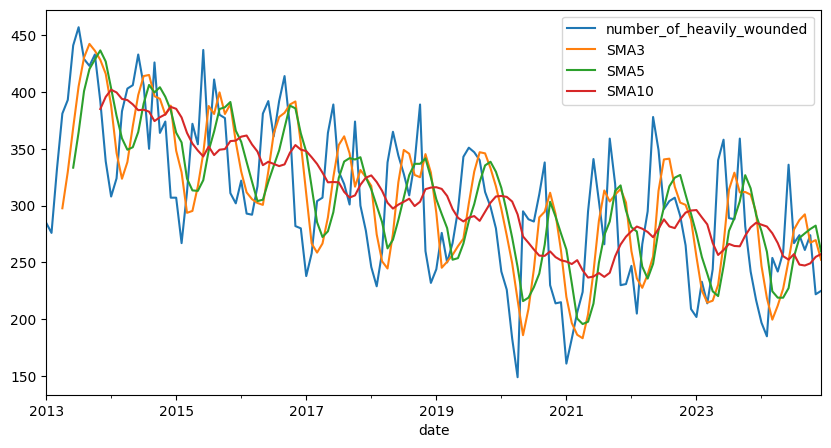

In [ ]:
wounded_data.plot(
    y=['number_of_heavily_wounded', 'SMA3',	'SMA5',	'SMA10'],
    figsize=(10,5));

As you will notice, SMA's with a short window will still follow fluctuations in the observations, while those with a longer window are more "stable", and resilient to short-term fluctuations.

As mentioned before, there are multiple criticisms to the moving average method. First, it puts equal weight
on each value in a typical moving average. But one can argue that if the next month's forecast should be based on the observations of the past 12 months, more weight should be placed on the more recent observations. The second criticism is that the moving averages method requires a lot of data storage.

### Exercise

Calculate the MAE for the values of 2024 in case of SMA3, SMA5, SMA10.  
Do these models perform better than simple linear regression?

In [ ]:
y_true = wounded_data['number_of_heavily_wounded'][-12:].values





## (4) Simple Exponentional Smoothing (SES)

We now consider Simple Exponential Smoothing, which is a more advanced model than the simple moving average.

### Why is this useful?

- It gives **more weight to recent observations**, making it more responsive to changes.
- It requires **very little data storage** (only the last forecast and observation).
- It is relatively **simple to understand and implement**.
- It is widely used in business, especially when many forecasts need to be updated frequently and automatically.


### Why is this better than Simple Moving Average?

- It does not treat all past observations equally.
- It reacts faster to recent changes in the data.
- It avoids the need to store a fixed window of past values.


### When should we use it?

Simple Exponential Smoothing is appropriate when:
- the data has **no clear trend**, and
- there is **no seasonality**.


### Limitations

- It does not capture **trends** or **seasonal patterns**.
- The choice of $\alpha$ can strongly influence the results.
- It may lag behind rapid changes if $\alpha$ is too small.


### How does it work?

In Simple Exponential Smoothing, each forecast is calculated as a weighted average of past observations, where the weights decrease exponentially over time.  
Every exponential model has at least one smoothing constant, which is always a
number between 0 and 1. Simple exponential smoothing has a single smoothing constant denoted by $\alpha$. The second new term is $L_t$, called the level of
level the series at time t. This value is not observable but can only be estimated. Essentially, it is an estimate of where the series would be at time $t$ if there were no random noise. Then the simple exponential smoothing method is defined by the following two equations:

Level:

$L_t = \alpha Y_t + (1 - \alpha) L_{t-1}$

Forecast:
$F_{t+k} = L_t$

where:

- $\alpha$ is the smoothing parameter (between 0 and 1)
- $Y_{t}$ is the most recent observation
- ${L}_{t-1}$ is the previous forecast

Even though you usually don't have to substitute into these equations manually, you should understand what they say.  
The first of both equation shows how to update the estimate of the level. It is a weighted average of the current observation, $Y_t$ and the previous level, $L_{t-1}$, with respective weights $\alpha$ and $(1 - \alpha)$.   

The second equation shows how forecasts are made. It says
that the k-period-ahead forecast, $F_{t+k}$, made of $Y_{t+k}$ in period $t$ is the most recently estimated level, $L_t$. This is the same for any value of $k$ ≥ 1. The idea is that in simple exponential smoothing, you believe that the series is not really going anywhere. So as soon as you
estimate where the series ought to be in period $t$ (if it weren’t for random noise), you use this as the forecast for any future period.

The smoothing constant $\alpha$ is analogous to the span in moving averages. By performing some algebra, you can verify that $L_t$ satifies the following equation, where sum extends back to the first observation at time = 1.

$L_t = \alpha Y_{t} + \alpha (1 - \alpha) Y_{t-1} + \alpha (1 - \alpha)^2 Y_{t-2} + \alpha (1 - \alpha)^3 Y_{t-3} + ...$

This equation shows how the exponentially smoothed forecast is a weighted average of previous observations. Furthermore, because 1 − $\alpha$ is less than 1, the weights on the $Y$'s decrease from time t backward.   
If $\alpha$ is close to 0, then 1 − $\alpha$ is close to 1 and the weights
decrease very slowly. In other words, observations from the distant past continue to have a large influence on the next forecast. This means that the graph of the forecasts will be relatively
smooth, just as with a large span in the moving averages method. But if $\alpha$ is close to 1, the weights decrease rapidly, and only very recent observations have much influence on
the next forecast. In this case forecasts react quickly to sudden changes in the series.

### Example


In [ ]:
# We use the library statsmodels!
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Train the model
data_ses = SimpleExpSmoothing(wounded_data['number_of_heavily_wounded']).fit(smoothing_level=0.1, optimized=False)

# Add fitted values to the dataframe
wounded_data['SES'] = data_ses.level
wounded_data.head(10)

,number_of_heavily_wounded,SMA3,SMA5,SMA10,SES
date,,,,,
2013-01-01,285,NaN,NaN,NaN,285.000000
2013-02-01,276,NaN,NaN,NaN,284.100000
2013-03-01,332,NaN,NaN,NaN,288.890000
2013-04-01,381,297.666667,NaN,NaN,298.101000
2013-05-01,393,329.666667,NaN,NaN,307.590900
2013-06-01,441,368.666667,333.4,NaN,320.931810
2013-07-01,457,405.000000,364.6,NaN,334.538629
2013-08-01,429,430.333333,400.8,NaN,343.984766
2013-09-01,423,442.333333,420.2,NaN,351.886289


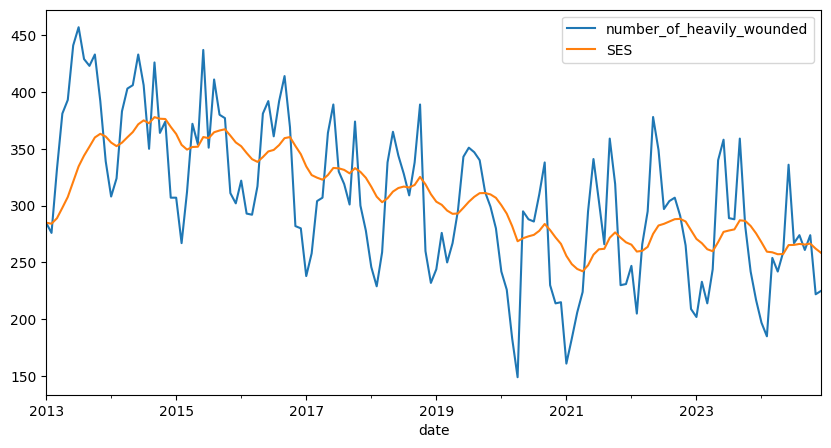

In [ ]:
wounded_data.plot(y=['number_of_heavily_wounded',  'SES'], figsize=(10,5));

We can retrieve the automatically calculated parameters of the model: use `. params_formatted` to obtain a dataframe containing all parameters.

In [ ]:
data_ses.params_formatted

,name,param,optimized
smoothing_level,alpha,0.1,False
initial_level,l.0,285.0,False


### Exercise
Use these parameters to verify that the values in the SES column are correct.

**`.forecast`**  
The statsmodels classes allow us to do a prediction based on the model:

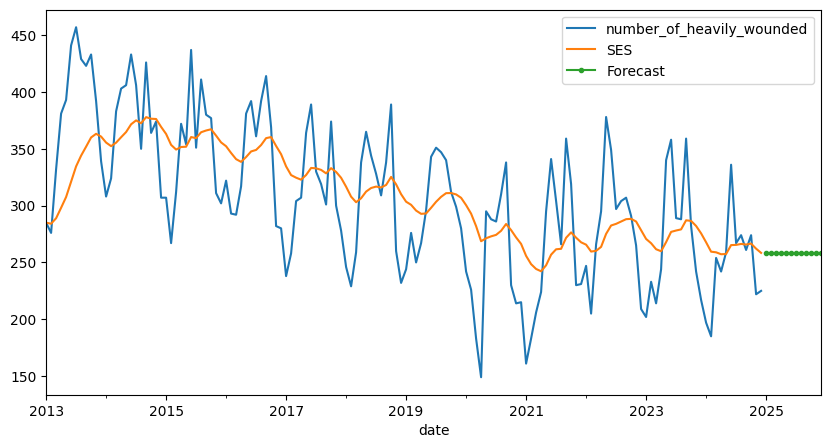

In [ ]:
data_ses_fcast = data_ses.forecast(12)

wounded_data.plot(y=['number_of_heavily_wounded',  'SES'], figsize=(10,5))
data_ses_fcast.plot(marker='.', legend=True, label='Forecast');

If we look back at the formulae of Single Exponential Smoothing, the forecasted value for any time of $k >= 1$ is the _level_ of the series at time $t$:

$L_t = \alpha Y_t + (1 - \alpha) L_{t-1}$    

$F_{t+k} = L_t$  

If we take a look at the plot, this looks correct, but let's check if this is actually the case using the data coming out of the model.  
First we retrieve the last level's $L_t$ of the model

In [ ]:
# data_ses.level[-1] is depricated. To access a value by position, use `ser.iloc[pos]`
data_ses.level.iloc[-1]

np.float64(258.41826050561957)

Now we print out the forecasted values:

In [ ]:
data_ses_fcast.values

array([258.41826051, 258.41826051, 258.41826051, 258.41826051,
       258.41826051, 258.41826051, 258.41826051, 258.41826051,
       258.41826051, 258.41826051, 258.41826051, 258.41826051])

We can see that the last value of `data_ses.level` is indeed the same as all the forecasted values for k >= 1.

When we use Single Exponential Smoothing, we assume that the underlying time series fluctutates around some constant value. This is what is reflected by the forecasted values (in green), which are always the same.



### Exercise

As in the previous paragraphs, calculate the MAE assuming the trainingsdata is all the available data upto and including 2023 and the test data is the data from 2024. Be aware which value to use as prediction for 2024!

In [ ]:
y_true = wounded_data['number_of_heavily_wounded'][-12:].values



**`.fittedvalues`**  
Sometimes we want to compare the actual, observed value to the value that was predicted by the model. In the previous example, we saw that the value  $L_t$  at time $t$ is the model's prediction for the actual value at time $t + 1$.
So, to calculate the difference between the actual, observed value (at time $t + 1$) and the predicted value (at time $t$), we would need to shift the column `data['SES']` one down and make the difference between the columns `data['number_of_heavily_wounded']` and `data['SES']`. This seems quite a burden. Luckily `.fittedvalues` is there to come to the rescue: it contains the value predicted by the model at time $t$.

In [ ]:
wounded_data['SES_predicted_value'] = data_ses.fittedvalues
wounded_data.tail()

,number_of_heavily_wounded,SMA3,SMA5,SMA10,SES,SES_predicted_value
date,,,,,,
2024-08-01,274,287.333333,271.6,248.1,266.296846,265.440940
2024-09-01,261,292.333333,275.6,247.3,265.767161,266.296846
2024-10-01,274,267.333333,279.4,249.2,266.590445,265.767161
2024-11-01,222,269.666667,282.4,254.9,262.131401,266.590445
2024-12-01,225,252.333333,259.6,257.4,258.418261,262.131401


Finally we can also retrieve the automatically calculated parameters of the model: use .params_formatted to obtain a dataframe containing all parameters:

## (5) Double exponential smoothing (Holt’s Method)

We now consider a more advanced model that can handle trends in the data. Unlike simple exponential smoothing, this method does not assume that the data fluctuates around a constant level. Instead, it allows the series to increase or decrease over time.

In this approach, we model both the **level** and the **trend** of the series:

Level:  
$L_{t} = \alpha Y_{t} + (1-\alpha)(L_{t-1} + T_{t-1})$

Trend:  
$T_{t} = \beta(L_{t}-L_{t-1}) + (1-\beta)T_{t-1}$

Forecast:  
$F_{t+k} = L_t + kT_t$

where:  

- $\alpha$ controls the smoothing of the level (between 0 and 1)
- $\beta$ controls the smoothing of the trend (between 0 and 1)
- $L_{t}$ is the level at time $t$
- ${T}_{t}$ is the trend at time $t$

These equations are not as bad as they look. (And don’t forget that the Python does all of the calculations for you.)   
The first equation says that the updated level is a weighted average of the current observation and the previous level plus the estimated change.  
The second equation says that the updated trend is a weighted average of the difference between two consecutive levels and the previous trend.  
The third equation says that the $k$-period-ahead forecast made in period $t$ is the estimated level plus $k$ times the estimated change per period.

Everything that was said about $\alpha$ for single exponential smoothing applies to both $\alpha$ and $\beta$ in Holt's model. The new smoothing constant $\beta$ controls how quickly the method reacts to observed changes in the trend. If $\beta$ is small, the method reacts slowly. If it is large, the method reacts more quickly.

### How does it work (intuitively)?

- The model looks at the most recent observation.
- It adjusts its estimate of the current level.
- It updates its estimate of the trend (is the data going up or down?).
- It combines both to make a forecast.

So instead of predicting a constant value, the model predicts a value that follows the direction of the data.

### Why is this useful?

- It captures **trends** in the data (increasing or decreasing patterns).
- It is more flexible than simple exponential smoothing.
- It still requires relatively **little data storage**.
- It produces more accurate forecasts when a trend is present.

### Why is this better than Simple Exponential Smoothing?

- It explicitly models the **trend component**.
- It adapts when the data is steadily increasing or decreasing.
- It provides better forecasts for data with a clear direction over time.

### When should we use it?

Double exponential smoothing is appropriate when:
- the data shows a **trend**, and
- there is **no strong seasonality**.

### Limitations

- It does not capture **seasonal patterns**.
- The choice of $\alpha$ and $\beta$ can strongly influence the results.
- It may perform poorly if the trend changes rapidly.

### Conclusion

Double exponential smoothing extends simple exponential smoothing by including a trend component. It is a practical and widely used method when data exhibits a clear upward or downward trend, but it remains limited when seasonal patterns are present.

### Example

In Python, you can instantiate the class [`Holt`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.Holt.html#statsmodels.tsa.holtwinters.Holt) and call the [`fit()`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.Holt.fit.html#statsmodels.tsa.holtwinters.Holt.fit) method. The smoothing parameters $\alpha$ and $\beta$ can be set with arguments `smoothing_level` and `smoothing_trend`, respectively. If you don't specify these, suitable values will be calculated using some rule of thumb.

In [ ]:
from statsmodels.tsa.api import Holt

data_des = Holt(wounded_data['number_of_heavily_wounded']).fit(smoothing_level=.1, smoothing_trend=.2, optimized=False)

wounded_data['DES'] = data_des.level
wounded_data.head()


,number_of_heavily_wounded,SMA3,SMA5,SMA10,SES,SES_predicted_value,DES
date,,,,,,,
2013-01-01,285,NaN,NaN,NaN,285.0000,285.000,276.900000
2013-02-01,276,NaN,NaN,NaN,284.1000,285.000,268.872000
2013-03-01,332,NaN,NaN,NaN,288.8900,284.100,267.389360
2013-04-01,381,297.666667,NaN,NaN,298.1010,288.890,272.247197
2013-05-01,393,329.666667,NaN,NaN,307.5909,298.101,279.994306


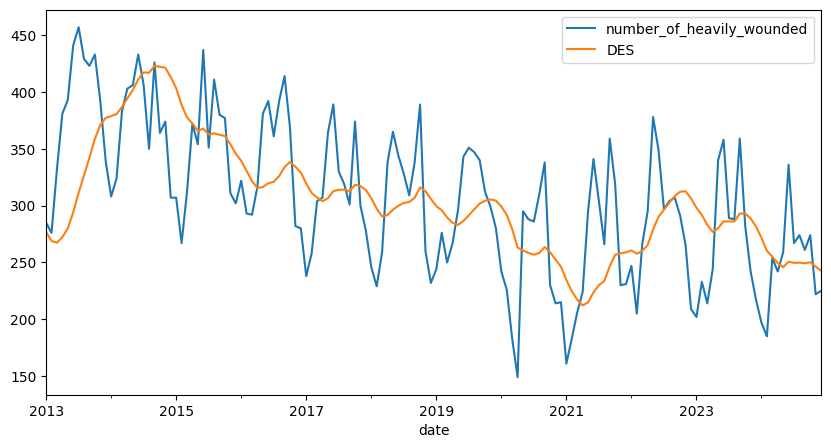

In [ ]:
wounded_data.plot(y=['number_of_heavily_wounded',  'DES'], figsize=(10,5));

We can retrieve the parameters of the model (smoothing parameters, initial estimate of constant term and trend):

In [ ]:
data_des.params_formatted

,name,param,optimized
smoothing_level,alpha,0.1,False
smoothing_trend,beta,0.2,False
initial_level,l.0,285.0,False
initial_trend,b.0,-9.0,False


In [ ]:
data_des.level

,0
date,
2013-01-01,276.900000
2013-02-01,268.872000
2013-03-01,267.389360
2013-04-01,272.247197
2013-05-01,279.994306
...,...
2024-08-01,249.858626
2024-09-01,249.228868
2024-10-01,250.197509


In [ ]:
data_des.trend

,0
date,
2013-01-01,-8.820000
2013-02-01,-8.661600
2013-03-01,-7.225808
2013-04-01,-4.809079
2013-05-01,-2.297841
...,...
2024-08-01,-1.937661
2024-09-01,-1.676080
2024-10-01,-1.147136


### Exercise

Use these parameters to verify that the values in the DES column are correct.

To use this model for forecasting:

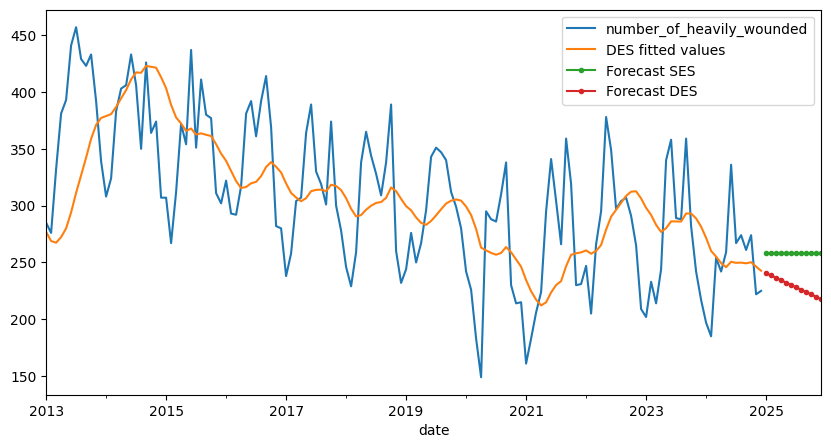

In [ ]:
data_des_fcast = data_des.forecast(12)

# Plot observations, fitted values and forecast
wounded_data['number_of_heavily_wounded'].plot(legend=True)
wounded_data['DES'].plot(legend=True, label='DES fitted values', figsize=(10,5));
data_ses_fcast.plot(marker='.', legend=True, label='Forecast SES');
data_des_fcast.plot(marker='.', legend=True, label='Forecast DES');

As we can see, the predictions are now:


In [ ]:
data_des_fcast

,0
2025-01-01,240.610185
2025-02-01,238.528898
2025-03-01,236.447610
2025-04-01,234.366323
2025-05-01,232.285035
2025-06-01,230.203748
2025-07-01,228.122461
2025-08-01,226.041173
2025-09-01,223.959886
2025-10-01,221.878598


The formula for predicting values, looks like this:

$F_{t+k} = L_t + kT_t$

Take a look at the values of the level's $L_t$ and the trend $T_t$, to  understand the predicted values, as are printed here before.
*   Explain the forecasted value of 2025-01-01
*   Explain the forecasted value of 2025-02-01
*   ...



In [ ]:
data_des.level.iloc[-1]

np.float64(242.6914726599233)

In [ ]:
data_des.trend.iloc[-1]

np.float64(-2.081287440717265)

In [ ]:
# predictions
data_des.level.iloc[-1] + data_des.trend.iloc[-1] * 2

np.float64(238.52889777848878)

Again, we can use .fittedvalues to compare the predicted value at time $t$ to the actual, observed value at time $t$.

In [ ]:
wounded_data['DES_fittedvalues'] = data_des.fittedvalues
wounded_data.tail()

,number_of_heavily_wounded,SMA3,SMA5,SMA10,SES,SES_predicted_value,DES,DES_fittedvalues
date,,,,,,,,
2024-08-01,274,287.333333,271.6,248.1,266.296846,265.440940,249.858626,247.176251
2024-09-01,261,292.333333,275.6,247.3,265.767161,266.296846,249.228868,247.920964
2024-10-01,274,267.333333,279.4,249.2,266.590445,265.767161,250.197509,247.552788
2024-11-01,222,269.666667,282.4,254.9,262.131401,266.590445,246.345335,249.050373
2024-12-01,225,252.333333,259.6,257.4,258.418261,262.131401,242.691473,244.657192


### Exercise

As in the previous paragraphs, calculate the MAE assuming the trainingsdata is all the available data upto and including 2023 and the test data is the data from 2024. Be aware which values to use as prediction for 2024!

In [ ]:
y_true = wounded_data['number_of_heavily_wounded'][-12:].values



## (6) Triple Exponential Smoothing (Holt - Winters method)

We now consider a model that can handle both trends and seasonality in the data. Unlike the previous methods, this model assumes that the data may follow a repeating pattern over time (for example, monthly or yearly cycles), in addition to increasing or decreasing.

In this approach, the model keeps track of three components:
- the **level** (the current value of the series),
- the **trend** (the direction of change),
- the **seasonal component** (the repeating pattern).

By combining these three elements, the model can produce forecasts that follow both the long-term direction and the recurring seasonal behavior of the data.

How can you tell whether there is seasonality in a time series? The easiest way is to check whether a graph of the time series has a regular pattern of ups and/or downs in particular months or quarters.

In an **additive seasonal model**, an appropriate seasonal index is added to a base
forecast.

In a **multiplicative seasonal model**, a base forecast is multiplied by an appropriate
seasonal index.


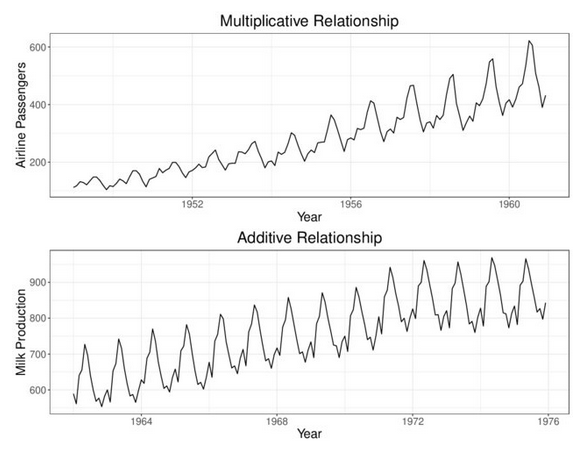


### Formulas for Holt-Winters with additive seasonal component

Level:  
$L_{t} = \alpha (Y_{t} - S_{t-m}) + (1-\alpha) (L_{t-1} + T_{t-1})$

Trend:   
$T_{t} = \beta (L_{t} - L_{t-1}) + (1-\beta)T_{t-1}$  

Seasonal component:   
$S_{t} = \gamma (Y_{t} - L_{t}) + (1-\gamma)S_{t-m}$  

Forecast for $k$ time units after the last observation:   
$F_{t+k} = L_{t} + kT_{t} + S_{t-m+k}$

In these formulas, the following additional notation is used:

- $m$ is the length (in number of time units) of the seasonal cycle. Common values are 7 for a weekly cycle, 4 for a quarterly one, 12 for a yearly cycle, etc.
- $0 < \gamma < 1$ is the smoothing parameter for the seasonal trend (like $\alpha$ and $\beta$). This new smoothing constant controls how quickly the method reacts to observed changes in the seasonality pattern. If $\gamma$ is small, the method reacts slowly. If it is large, the method reacts more
quickly. Set this value in the `fit()` method using argument `smoothing_seasonal`.
- $S_t$ are estimates for the seasonal correction factors, one for each time unit within the seasonal cycle.

To understand how the forecast equation works in the additive Holt-Winters model, suppose you have observed data through June and you want to forecast September, which is three periods ahead. (Here, t refers to June and t+k=t+3 refers to September.)

The method starts by taking the current level and adding 3 times the current trend. This gives a baseline forecast for September that represents where the series would be if there were no seasonal effects.

Next, the method adds the seasonal component: it adds the most recent estimate of the seasonal effect for September (typically taken from the previous September, i.e., $S_{t−m+3}$).

So, the final forecast for September is obtained by:
* projecting the level forward using the trend, and
* then adding the appropriate seasonal adjustment.

This additive structure is appropriate when the seasonal fluctuations remain roughly constant in size, regardless of the level of the time series.

Note that in the forecast formula of the additive Holt-Winters model, you need to make sure that you use the correct seasonal index.
Since the seasonal component repeats in cycles, you must “loop back” through the seasons when forecasting further ahead.

So, continuing from the previous example (forecasting September based on June), if you forecast further, for example 15 months ahead, you “wrap around” the seasons:

* 15 months ahead of June is again September
* So you still use the September seasonal index

### Intuitive Explanation

Think of this model as combining three ideas:

1. **Where are we now?** → the current level  
2. **Where are we going?** → the trend  
3. **What time of the cycle is it?** → the seasonal pattern  

At each step:
- the model updates its estimate of the current level,
- it adjusts the trend (is the data going up or down?),
- and it accounts for the position within the seasonal cycle (e.g., winter vs. summer).

For example, if sales are generally increasing over time but are always higher in December, the model will:
- follow the upward trend, and  
- add a seasonal boost for December.

### Why is this useful?

- It captures **trend and seasonality at the same time**.
- It produces more accurate forecasts for data with repeating patterns.
- It adapts over time as new data becomes available.
- It is widely used in practice for business and economic time series.

### When should we use it?

Triple exponential smoothing is appropriate when:
- the data shows a **trend**, and  
- there is a **clear seasonal pattern** (e.g., monthly or yearly cycles).

### Limitations

- It is more complex than previous methods.
- It requires choosing several parameters (for level, trend, and seasonality).
- It may perform poorly if the seasonal pattern changes significantly over time.

### Conclusion

This model predicts future values by combining the current level, the direction of change, and repeating seasonal patterns.

### Example

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

data_tes = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()

wounded_data['TES'] = data_tes.level
# Notice there is NaN for 2024 in column TES!
wounded_data.tail(24)

,number_of_heavily_wounded,SMA3,SMA5,SMA10,SES,SES_predicted_value,DES,DES_fittedvalues,TES
date,,,,,,,,,
2023-01-01,202,255.000000,275.2,296.1,270.693526,278.326140,298.067357,308.741508,268.757426
2023-02-01,233,225.333333,254.8,289.7,266.924173,270.693526,291.793749,298.326387,274.263239
2023-03-01,214,214.666667,240.0,283.5,261.631756,266.924173,283.071626,290.746251,269.935869
2023-04-01,244,216.333333,224.6,267.1,259.868580,261.631756,276.840284,280.489204,267.011844
2023-05-01,340,230.333333,220.4,256.6,267.881722,259.868580,280.175270,273.528077,273.917073
2023-06-01,358,266.000000,246.6,260.9,276.893550,267.881722,286.173251,278.192502,278.219678
2023-07-01,289,314.000000,277.8,266.3,278.104195,276.893550,286.107970,285.786634,273.638922
2023-08-01,288,329.000000,289.0,264.5,279.093775,278.104195,286.007058,285.785620,270.322208
2023-09-01,359,311.666667,303.8,264.2,287.084398,279.093775,293.056095,285.728995,277.594313


Again, we can retrieve the internals of the model. These are the relevant attributes:

- `level` contains all level estimates ($L_i$) for each time unit in the training data
- `trend` contains all trend estimates ($T_i$)
- `season` contains all estimates for the seasonal adjustment factors. ($S_i$)
- `params` (dict output) or `params_formatted` (table output) contains all parameters used to bootstrap the model (including automatically calculated ones).

In [ ]:
data_tes.params_formatted

,name,param,optimized
smoothing_level,alpha,0.212327,True
smoothing_trend,beta,0.000000,True
smoothing_seasonal,gamma,0.000000,True
initial_level,l.0,373.832397,True
initial_trend,b.0,-0.808378,True
initial_seasons.0,s.0,-62.587319,True
initial_seasons.1,s.1,-64.687045,True
initial_seasons.2,s.2,-42.881435,True
initial_seasons.3,s.3,-15.163413,True
initial_seasons.4,s.4,37.467699,True


To use this model for forecasting:

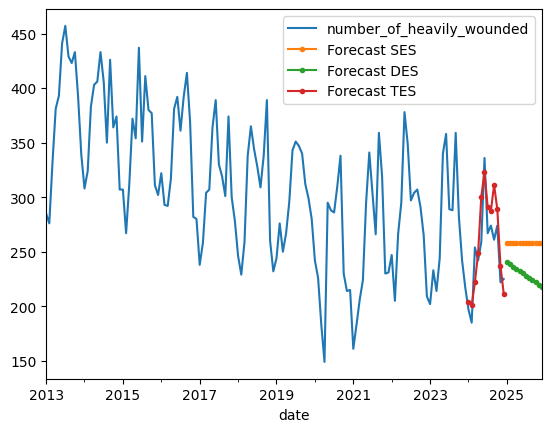

In [ ]:
# forecast is now for the values of 2024!
data_tes_fcast = data_tes.forecast(12)

# Plot observations, fitted values and forecast
wounded_data['number_of_heavily_wounded'].plot(legend=True)
data_ses_fcast.plot(marker='.', legend=True, label='Forecast SES');
data_des_fcast.plot(marker='.', legend=True, label='Forecast DES');
data_tes_fcast.plot(marker='.', legend=True, label='Forecast TES');

As we can see, the predictions are now:


In [ ]:
data_tes_fcast

,0
2024-01-01,203.717125
2024-02-01,200.809021
2024-03-01,221.806252
2024-04-01,248.715896
2024-05-01,300.538629
2024-06-01,323.082620
2024-07-01,290.809671
2024-08-01,287.628784
2024-09-01,311.266872
2024-10-01,288.993413


### Exercise
As in the previous paragraphs, calculate the MAE assuming the trainingsdata is all the available data upto and including 2023 and the test data is the data from 2024. Be aware which values to use as prediction for 2024!

In [ ]:
y_true = wounded_data['number_of_heavily_wounded'][-12:].values


Forecasting is done using the final values for the level, trend and seasonal adjustment factor estimates. Let's retrieve them from the model:

In [ ]:
wounded_hw.level.iloc[-1]

np.float64(267.11282146039713)

In [ ]:
wounded_hw.trend.iloc[-1]

np.float64(-0.8083781352409689)

In [ ]:
wounded_hw.season.iloc[-12:]

,0
date,
2023-01-01,-62.587319
2023-02-01,-64.687045
2023-03-01,-42.881435
2023-04-01,-15.163413
2023-05-01,37.467699
2023-06-01,60.820067
2023-07-01,29.355497
2023-08-01,26.982987
2023-09-01,51.429454


### Exercise
The formula for predicting values, looks like this:

$F_{t+k} = L_{t} + kT_{t} + S_{t-m+k}$

Take a look at the values of the level's $L_t$ and the trend $T_t$, to  understand the predicted values, as are printed here before.

The model performs forecasts by:

- Taking the last level estimate
- Taking the last trend estimate
- Taking the last estimate for the appropriate seasonal adjustment factor
- Computing the forecast formula given above

*   Explain the forecasted value of 2024-01-01
*   Explain the forecasted value of 2024-02-01
*   ...

In [ ]:
data_tes.forecast(12)

,0
2024-01-01,203.717125
2024-02-01,200.809021
2024-03-01,221.806252
2024-04-01,248.715896
2024-05-01,300.538629
2024-06-01,323.082620
2024-07-01,290.809671
2024-08-01,287.628784
2024-09-01,311.266872
2024-10-01,288.993413


### Decomposing a time series

A data series that shows a long term and seasonal trend can be "decomposed":

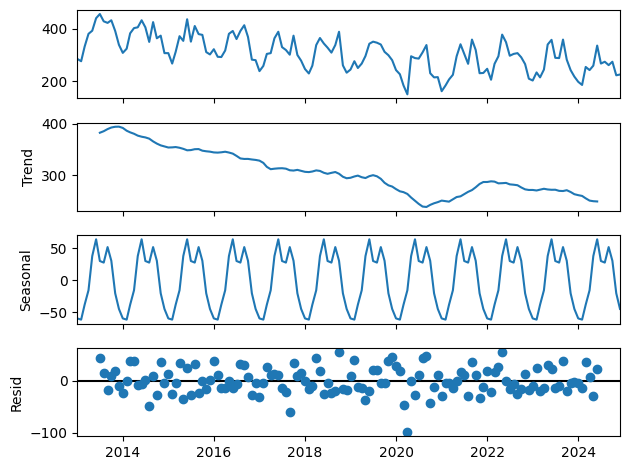

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# remove other columns (e.g. SES, DES, ...)
data = wounded_data[['number_of_heavily_wounded']]

wounded_decomposed = seasonal_decompose(data, model='additive')
wounded_decomposed.plot();

- The top graph shows the observations
- The second graph is the long term trend (which seems to be linear, so the choice for an additive model was appropriate)
- The third graph shows the seasonal trend
- The final graph are the residues

The semicolon at the end of line 4 is not strictly necessary, but if you leave it out, it's possible that the plot is shown twice.




## Sources

Khan, E. (2021-01-05) *Python Code on Holt-Winters Forecasting.* Retrieved 2022-04-15 from <https://medium.com/analytics-vidhya/python-code-on-holt-winters-forecasting-3843808a9873>

Moreno, A.I. (2020-07-08) *Moving Averages with Python: Simple, cumulative and exponential moving averages with Pandas*, retrieved 2022-04-15 from <https://towardsdatascience.com/moving-averages-in-python-16170e20f6c>

Paramita (2020-12-17) *Holt winters Model, Easiest Times series Model. Additive multiplicative trend and seasonality*, retrieved 2022-04-16 from <https://www.youtube.com/watch?v=O6cUkdQeLUQ>

Perktold, J., et al. (2022-04-13) *statsmodels manual: Exponential Smoothing.* Retrieved 2022-04-15 from <https://www.statsmodels.org/dev/examples/notebooks/generated/exponential_smoothing.html>
